# Sentiment Model Evaluation

Compares the 5 fine-tuned models in `MODEL_REGISTRY` on the held-out test split: metrics bar charts plus each model's confusion matrix (generated by `evaluate.py`).

Run this notebook with its working directory set to `ml/` (same as the training/eval scripts).

In [1]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from src.sentiment.config import MODEL_REGISTRY, eval_output_dir

In [2]:
rows = []
for model_key, info in MODEL_REGISTRY.items():
    report_path = f"{eval_output_dir(model_key)}/classification_report.json"
    with open(report_path) as f:
        report = json.load(f)
    rows.append(
        {
            "model": model_key,
            "display_name": info["display_name"],
            "accuracy": report["accuracy"],
            "macro_f1": report["macro avg"]["f1-score"],
            "negative_f1": report["Negative"]["f1-score"],
            "positive_f1": report["Positive"]["f1-score"],
        }
    )

summary = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
summary

,model,display_name,accuracy,macro_f1,negative_f1,positive_f1
0,cardiffnlp-twitter,Twitter RoBERTa (cardiffnlp),0.990715,0.939171,0.883178,0.995165
1,roberta,RoBERTa (roberta-base),0.990529,0.937252,0.879433,0.995071
2,bert,BERT (bert-base-uncased),0.989601,0.931872,0.869159,0.994585
3,distilbert,DistilBERT (distilbert-base-uncased),0.988672,0.927886,0.861678,0.994094
4,nlptown-multilingual,Multilingual BERT (nlptown),0.986444,0.911389,0.829837,0.992941


## Metric comparison

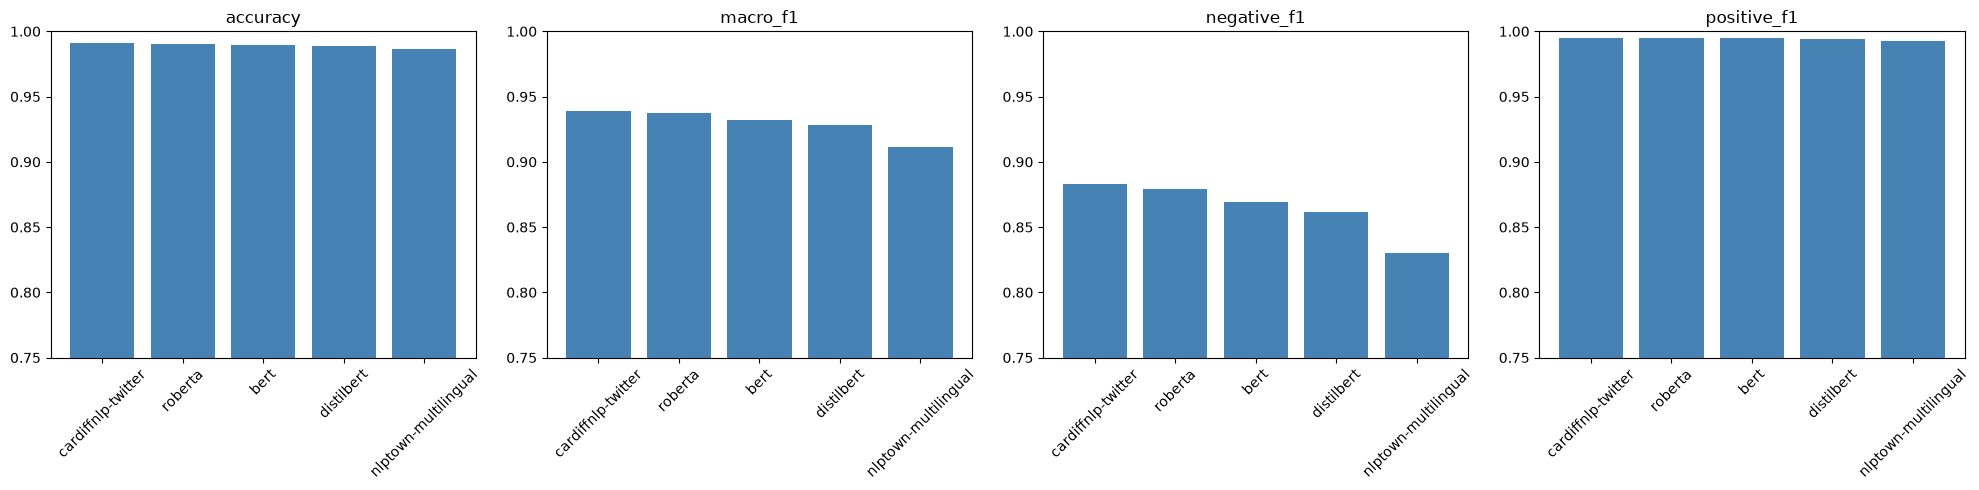

In [3]:
metrics = ["accuracy", "macro_f1", "negative_f1", "positive_f1"]
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))
for ax, metric in zip(axes, metrics):
    ax.bar(summary["model"], summary[metric], color="steelblue")
    ax.set_title(metric)
    ax.set_ylim(0.75, 1.0)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Confusion matrices

Each image was generated by `evaluate.py` during training/evaluation.

Twitter RoBERTa (cardiffnlp)


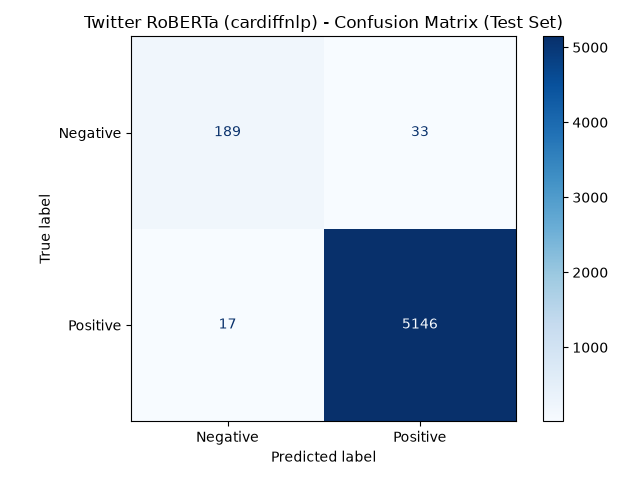

RoBERTa (roberta-base)


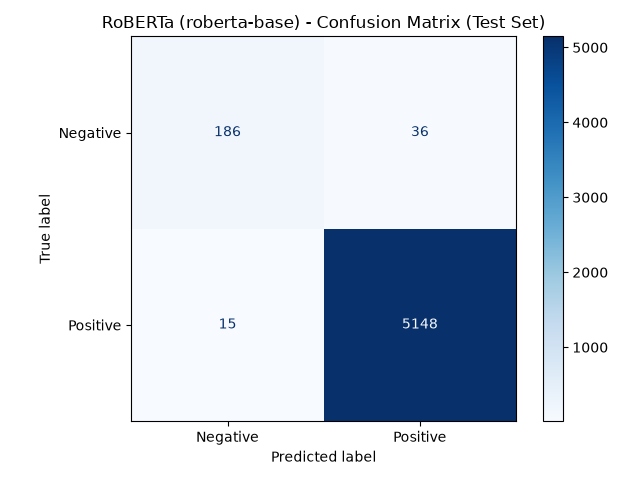

BERT (bert-base-uncased)


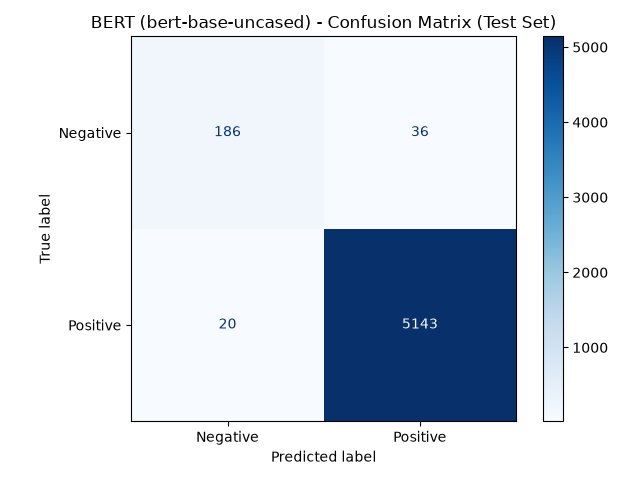

DistilBERT (distilbert-base-uncased)


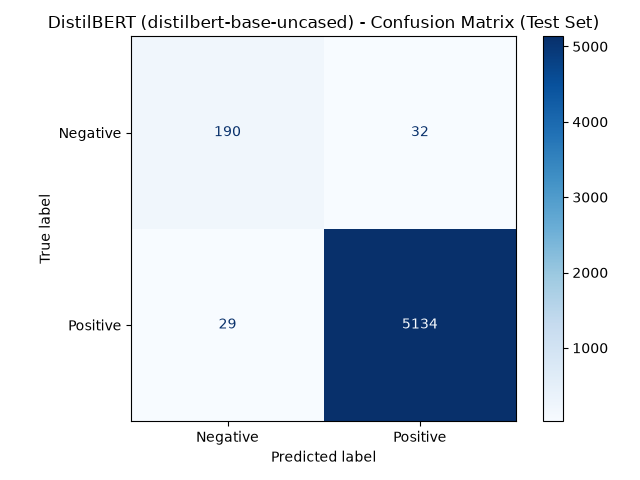

Multilingual BERT (nlptown)


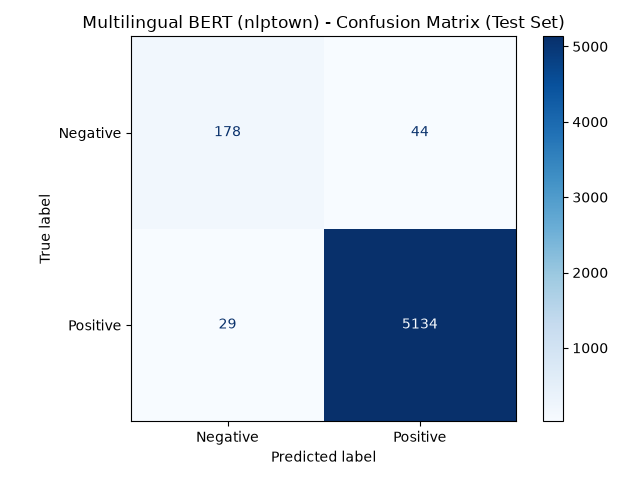

In [4]:
for model_key in summary["model"]:
    matrix_path = f"{eval_output_dir(model_key)}/confusion_matrix.png"
    print(MODEL_REGISTRY[model_key]["display_name"])
    if os.path.exists(matrix_path):
        display(Image(filename=matrix_path))
    else:
        print(f"  (missing: {matrix_path})")